In [ ]:
from Bio import Phylo
import baltic as bt
from pathlib import Path 
import pylab
import matplotlib.pyplot as plt
import matplotlib as mpl
import requests
from io import StringIO as sio
from matplotlib.lines import Line2D
import re
import inspect
import itertools
import numpy as np
from orthofinder_tools import create_plots
from IPython.display import SVG

In [ ]:
tree = Phylo.read(nwk, "newick")
print(tree)

tree.root_with_outgroup("vkomodo")


a, b = tree.root.clades
total = (a.branch_length or 0.0) + (b.branch_length or 0.0)
a.branch_length = total / 2.0
b.branch_length = total / 2.0

print(tree)


Tree(rooted=False, weight=1.0)
    Clade(branch_length=0.0)
        Clade(branch_length=0.17888, name='N1')
            Clade(branch_length=0.03833, name='caspera')
            Clade(branch_length=0.03588, name='N2')
                Clade(branch_length=0.03929, name='vberus')
                Clade(branch_length=0.01329, name='N3')
                    Clade(branch_length=0.02629, name='N4')
                        Clade(branch_length=0.00159, name='N6')
                            Clade(branch_length=0.01098, name='nscut')
                            Clade(branch_length=0.01157, name='ptext')
                        Clade(branch_length=0.01041, name='N7')
                            Clade(branch_length=0.0015, name='hcy')
                            Clade(branch_length=0.00023, name='N8')
                                Clade(branch_length=0.00044, name='N9')
                                    Clade(branch_length=0.00166, name='hcurw')
                                    Clade(branch_l

### **Species Tree**

In [ ]:
og = "/hpcfs/users/a1864358/sanders_lab/phylogenomics/orthofinder/orthofinder_prot/primary_transcripts_lifted/OrthoFinder/Results_lifted/Species_Tree/SpeciesTree_rooted_node_labels.txt"

nwk = "/hpcfs/users/a1864358/sanders_lab/phylogenomics/orthofinder/orthofinder_prot/primary_transcripts_lifted/OrthoFinder/Results_lifted/Species_Tree/SpeciesTree_rooted_node_labels.nhx"

Phylo.convert(og, "newick", nwk, "newick")

1


Tree height: 0.180470
Tree length: 0.433810
strictly bifurcating tree

Numbers of objects in tree: 23 (11 nodes and 12 leaves)

[(<baltic.baltic.leaf object at 0x7fb94f6b8870>, 0.03929, 0.309575), (<baltic.baltic.leaf object at 0x7fb6d9adbf70>, 0.01157, 0.35033500000000006), (<baltic.baltic.leaf object at 0x7fb6d821e990>, 0.01098, 0.34945000000000004), (<baltic.baltic.node object at 0x7fb6d9b77290>, 0.03588, 0.23270000000000002), (<baltic.baltic.node object at 0x7fb6d9b77110>, 0.02629, 0.316655), (<baltic.baltic.node object at 0x7fb6d9b77c50>, 0.01041, 0.345415), (<baltic.baltic.node object at 0x7fb6d9b77950>, 0.01329, 0.270575), (<baltic.baltic.node object at 0x7fb6d9b76c90>, 0.08944, 0.13416), (<baltic.baltic.leaf object at 0x7fb6d9ada0d0>, 0.0161, 0.34241000000000005), (<baltic.baltic.node object at 0x7fb6d9b77350>, 0.02052, 0.30800000000000005), (<baltic.baltic.leaf object at 0x7fb6d9ad9a90>, 0.02134, 0.35027), (<baltic.baltic.leaf object at 0x7fb6d821fcf0>, 0.03833, 0.236375), (<

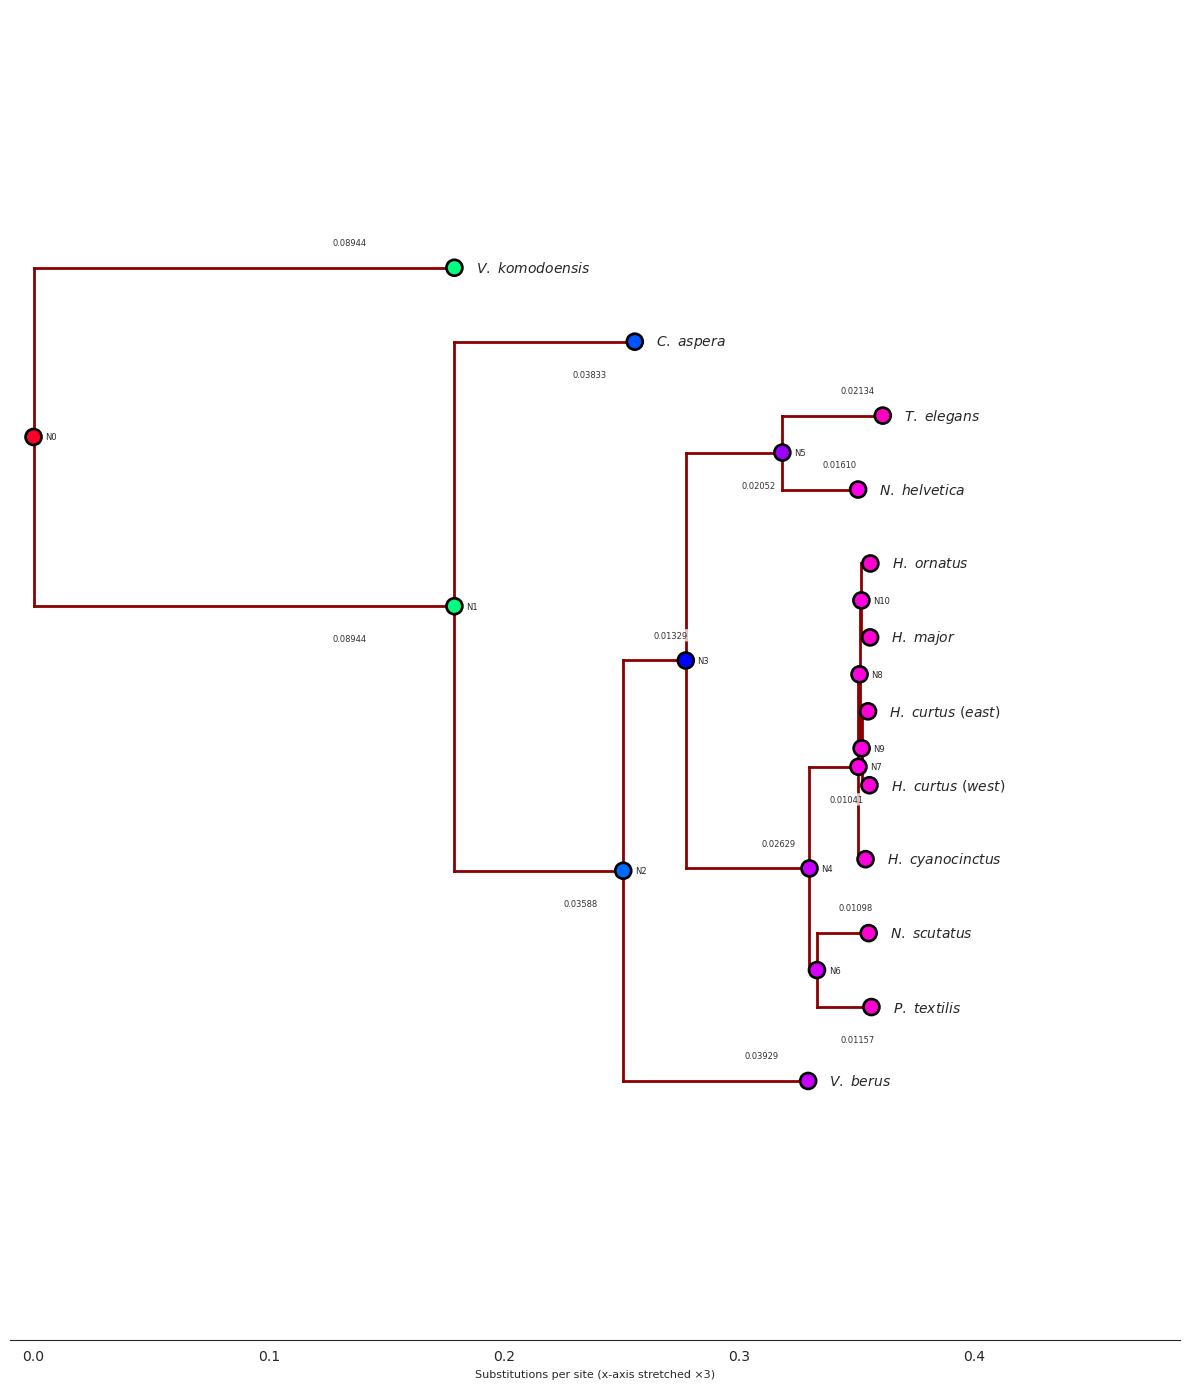

In [135]:
treeFile = Path(nwk)
SCALE = 2

ll = bt.loadNewick(str(treeFile), absoluteTime=False)
ll.treeStats()

def _max_terminal_length(k):
    if k.is_leaf():
        return k.length
    return max(_max_terminal_length(c) for c in k.children)

def sort_longest_outside(tree, node=None, outer_is_first=True):
    if node is None:
        node = tree.root
    if not getattr(node, "children", None):
        return
    node.children.sort(key=_max_terminal_length, reverse=outer_is_first)
    n = len(node.children)
    for i, child in enumerate(node.children):
        if not child.is_node():
            continue
        if n == 1:
            child_outer_first = outer_is_first
        elif i == 0:
            child_outer_first = True
        elif i == n - 1:
            child_outer_first = False
        else:
            child_outer_first = outer_is_first
        sort_longest_outside(tree, child, child_outer_first)
    if node is tree.root:
        tree.drawTree()

sort_longest_outside(ll)

cmap=mpl.cm.gist_rainbow
c_func=lambda k: cmap(k.height/ll.treeHeight)        


fig, ax = plt.subplots(figsize=(12, 14), facecolor="white")

# For ordinary OrthoFinder branch lengths -> height is substitutions/site.
x_attr = lambda k: k.height * SCALE

labels = []
for k in ll.Objects:
    bl = getattr(k, "length", None)
    if bl is None or bl < 0.005:
        continue
    labels.append((k, bl, x_attr(k) - bl / 2)) # (node, branch length, mid point)
    
labels.sort(key = lambda t: (t[0].y, t[2])) # by tip row, then x 
for i, (k, bl, x_mid) in enumerate(labels):
    dy = 0.28 if i % 2 == 0 else -0.38 # above / below
    ax.text(
        x_mid,
        k.y + dy,
        f"{bl:.5f}",
        ha="center",
        va="bottom" if dy > 0 else "top",
        fontsize=6,
        color="#333333",
        bbox=dict(boxstyle = "round,pad=0.20", facecolor = "white", edgecolor = "none", alpha = 0.75),
        zorder = 200,
    )

ll.plotTree(
    ax,
    x_attr=x_attr,
    colour="darkred",
    width=2.0,
    zorder=10,
)

ll.plotPoints(
    ax,
    x_attr=x_attr,
    y_attr = lambda k: k.y * 1,
    target=lambda k: k.is_node(),
    size=90,
    colour=c_func,
    zorder=100,
)

# Leaf markers
ll.plotPoints(
    ax,
    x_attr=x_attr,
    target=lambda k: k.is_leaf(),
    size=90,
    colour=c_func,
    zorder=100,
)

species_names = {
    "hmaj": "H. major",
    "hcure": "H. curtus (east)",
    "hcurw": "H. curtus (west)",
    "hcy": "H. cyanocinctus",
    "horn": "H. ornatus",
    "caspera": "C. aspera",
    "caviridis": "C. viridis",
    "nhel": "N. helvetica",
    "nscut": "N. scutatus",
    "ptext": "P. textilis",
    "tele": "T. elegans",
    "vberus": "V. berus",
    "vkomodo": "V. komodoensis",
}

for k in ll.getExternal():
    if k.is_leaf():
        spec = species_names.get(k.name, k.name)
        spec_i = spec.replace(" ", r"\ ")
        ax.text(
            x_attr(k) + 0.009,
            k.y,
            rf"$\it{{{spec_i}}}$",
            va="center",
            fontsize=10,
        )

for k in ll.getInternal():
    for key, value in k.traits.items():
        if k.is_node():
            ax.text(
                x_attr(k) + 0.005,
                k.y,
                value,
                va="center",
                fontsize=6,
            )
        
ax.set_ylim(-3, ll.ySpan + 3)
ax.set_yticks([])

for loc in ax.spines:
    ax.spines[loc].set_visible(loc == "bottom")

ax.set_xlabel("Substitutions per site", fontsize=8)

xmax = max(x_attr(k) for k in ll.Objects)

ax.set_xlim(-0.01, ll.treeHeight * SCALE * 1.35)
ax.set_xlabel("Substitutions per site (x-axis stretched ×3)", fontsize=8)

print(labels)
plt.tight_layout()
plt.show()


Tree height: 0.180470
Tree length: 0.433810
strictly bifurcating tree

Numbers of objects in tree: 23 (11 nodes and 12 leaves)



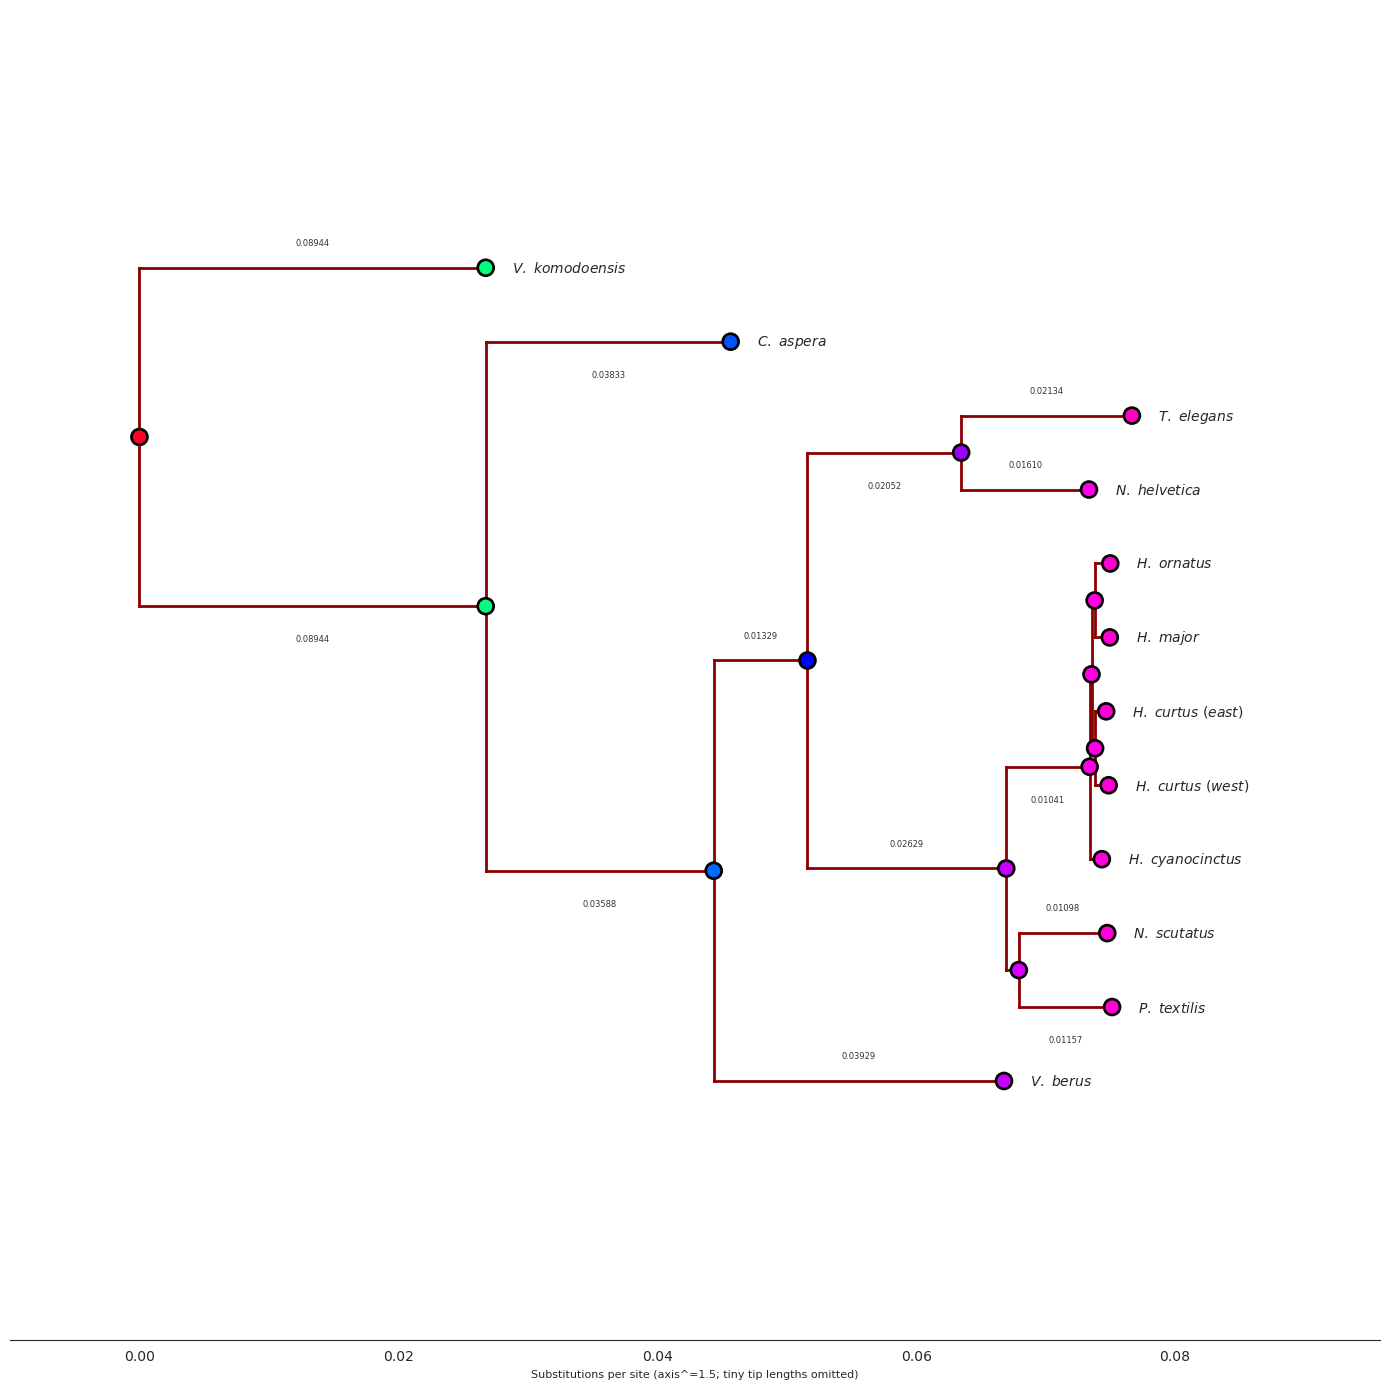

In [ ]:
treeFile = Path(nwk)

ll = bt.loadNewick(str(treeFile), absoluteTime=False)
ll.treeStats()

def _max_terminal_length(k):
    if k.is_leaf():
        return k.length
    return max(_max_terminal_length(c) for c in k.children)

def sort_longest_outside(tree, node=None, outer_is_first=True):
    if node is None:
        node = tree.root
    if not getattr(node, "children", None):
        return
    node.children.sort(key=_max_terminal_length, reverse=outer_is_first)
    n = len(node.children)
    for i, child in enumerate(node.children):
        if not child.is_node():
            continue
        if n == 1:
            child_outer_first = outer_is_first
        elif i == 0:
            child_outer_first = True
        elif i == n - 1:
            child_outer_first = False
        else:
            child_outer_first = outer_is_first
        sort_longest_outside(tree, child, child_outer_first)
    if node is tree.root:
        tree.drawTree()

sort_longest_outside(ll)

cmap = mpl.cm.gist_rainbow
c_func = lambda k: cmap(k.height / ll.treeHeight)

POWER = 1.5
def x_warp(h):
    return max(float(h), 0.0) ** POWER

fig, ax = plt.subplots(figsize=(14, 14), facecolor="white")
x_attr = lambda k: x_warp(k.height)

# only label longer branches 
labels = []
for k in ll.Objects:
    bl = getattr(k, "length", None)
    if bl is None or bl < 0.005:
        continue
    h_end = k.height
    h_start = max(h_end - bl, 0.0)
    x_mid = (x_warp(h_start) + x_warp(h_end)) / 2
    labels.append((k, bl, x_mid))

labels.sort(key=lambda t: (t[0].y, t[2]))
for i, (k, bl, x_mid) in enumerate(labels):
    dy = 0.28 if i % 2 == 0 else -0.38
    ax.text(
        x_mid, k.y + dy, f"{bl:.5f}",
        ha="center", va="bottom" if dy > 0 else "top",
        fontsize=6, color="#333333",
        bbox=dict(boxstyle="round,pad=0.20", facecolor="white",
                  edgecolor="none", alpha=0.75),
        zorder=200,
    )

ll.plotTree(ax, x_attr=x_attr, colour="darkred", width=2.0, zorder=10)
ll.plotPoints(ax, x_attr=x_attr, target=lambda k: k.is_node(),
              size=90, colour=c_func, zorder=100)
ll.plotPoints(ax, x_attr=x_attr, target=lambda k: k.is_leaf(),
              size=90, colour=c_func, zorder=100)

species_names = {
    "hmaj": "H. major", "hcure": "H. curtus (east)", "hcurw": "H. curtus (west)",
    "hcy": "H. cyanocinctus", "horn": "H. ornatus", "caspera": "C. aspera",
    "caviridis": "C. viridis", "nhel": "N. helvetica", "nscut": "N. scutatus",
    "ptext": "P. textilis", "tele": "T. elegans", "vberus": "V. berus",
    "vkomodo": "V. komodoensis",
}

for k in ll.getExternal():
    if k.is_leaf():
        spec = species_names.get(k.name, k.name)
        spec_i = spec.replace(" ", r"\ ")
        ax.text(x_attr(k) + 0.002, k.y, rf"$\it{{{spec_i}}}$",
                va="center", fontsize=10)

ax.set_ylim(-3, ll.ySpan + 3)
ax.set_yticks([])
for loc in ax.spines:
    ax.spines[loc].set_visible(loc == "bottom")

ax.set_xlim(-0.01, x_warp(ll.treeHeight) * 1.25)
ax.set_xlabel(f"Substitutions per site (axis^={POWER}; tiny tip lengths omitted)", fontsize=8)

plt.tight_layout()
plt.show()


In [109]:
# calc distances between neighbouring terminals

def terminal_neighbour_dist(tree):
    tips = list(tree.find_clades(terminal=True))
    return [(a.name, b.name, tree.distance(a, b)) for a, b in zip(tips, tips[1:])]

tre = Phylo.read(nwk, "newick")
pairs = terminal_neighbour_dist(tre)
for a, b, d in pairs:
    print(f"{a} -> {b}: {d:.5f}")

vkomodo -> caspera: 0.21721
caspera -> vberus: 0.11350
vberus -> nscut: 0.09144
nscut -> ptext: 0.02255
ptext -> hcy: 0.02507
hcy -> hcurw: 0.00383
hcurw -> hcure: 0.00302
hcure -> horn: 0.00410
horn -> hmaj: 0.00376
hmaj -> nhel: 0.07579
nhel -> tele: 0.03744


- units = substitutions / site

In [ ]:
create_plots(
    tree='/hpcfs/users/a1864358/sanders_lab/phylogenomics/orthofinder/orthofinder_prot/primary_transcripts_lifted/OrthoFinder/Results_lifted/Species_Tree/SpeciesTree_rooted_node_labels.txt',
    orthogroups_tsv='/hpcfs/users/a1864358/sanders_lab/phylogenomics/orthofinder/orthofinder_prot/primary_transcripts_lifted/OrthoFinder/Results_lifted/Orthogroups/Orthogroups.tsv',
    format='svg',
    no_labels=False,
    out='/hpcfs/users/a1864358/sanders_lab/phylogenomics/orthofinder/of_plots',
    figsize=(30, 10),
    tree_width=1,
    matrix_width=3,
    wspace=0.0
)

Pie data: {"core": 12762, "softcore": 0, "shell": 6701, "cloud": 100}


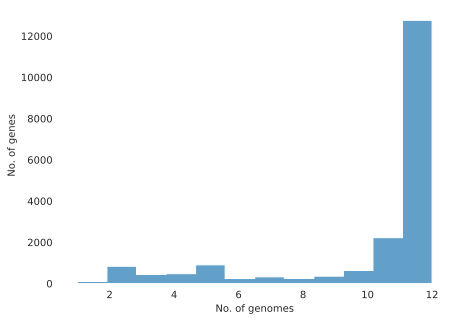

In [ ]:
SVG(filename='/hpcfs/users/a1864358/sanders_lab/phylogenomics/orthofinder/of_plots/pangenome_frequency.svg')

- peak @ 12 = shared by all species
- peak @ 5 = hydrophis
- peak @ 11 = all but V. komodoensis

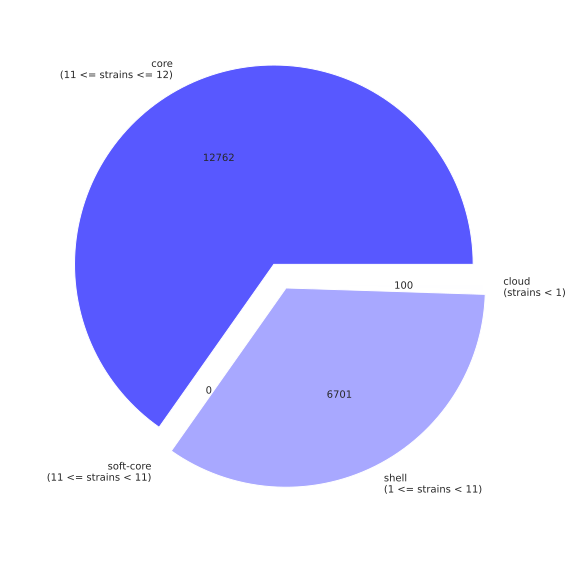

In [ ]:
SVG(filename='/hpcfs/users/a1864358/sanders_lab/phylogenomics/orthofinder/of_plots/pangenome_pie.svg')

- core = ≥99% genomes (≥11.88 → effectively all 12) = 12,762 (~65%)
    - => in (almost) every species. Here: all 12. These are the shared “housekeeping” gene set. ~65% of families.
- soft-core = 95–99% (11.4 ≤ n < 11.88) = 0
    - => in almost all, but not quite (Roary’s 95–99% band). With only 12 species that band is empty, so 0.
- shell = 15-95% (≈2–11 genomes) = 6,701 (~34%)
    - => some species but not all (here: 2–11). Variable / accessory families. ~34%.
- cloud = <15% (here 1 genome only) = 100 (~0.5%)
    - in very few species (here: just 1). Rare / private genes. ~0.5%.

In one line: most gene families are shared by everyone; a chunk are patchily shared; almost none are unique to a single species.

## Rooted Tree

In [139]:
nwk_rooted = Path(nwk).with_name("SpeciesTree_vkomodo_rooted.nwk")
Phylo.write(tree, nwk_rooted, "newick")
nwk_rooted = str(nwk_rooted)


Tree height: 0.180470
Tree length: 0.433810
strictly bifurcating tree

Numbers of objects in tree: 23 (11 nodes and 12 leaves)



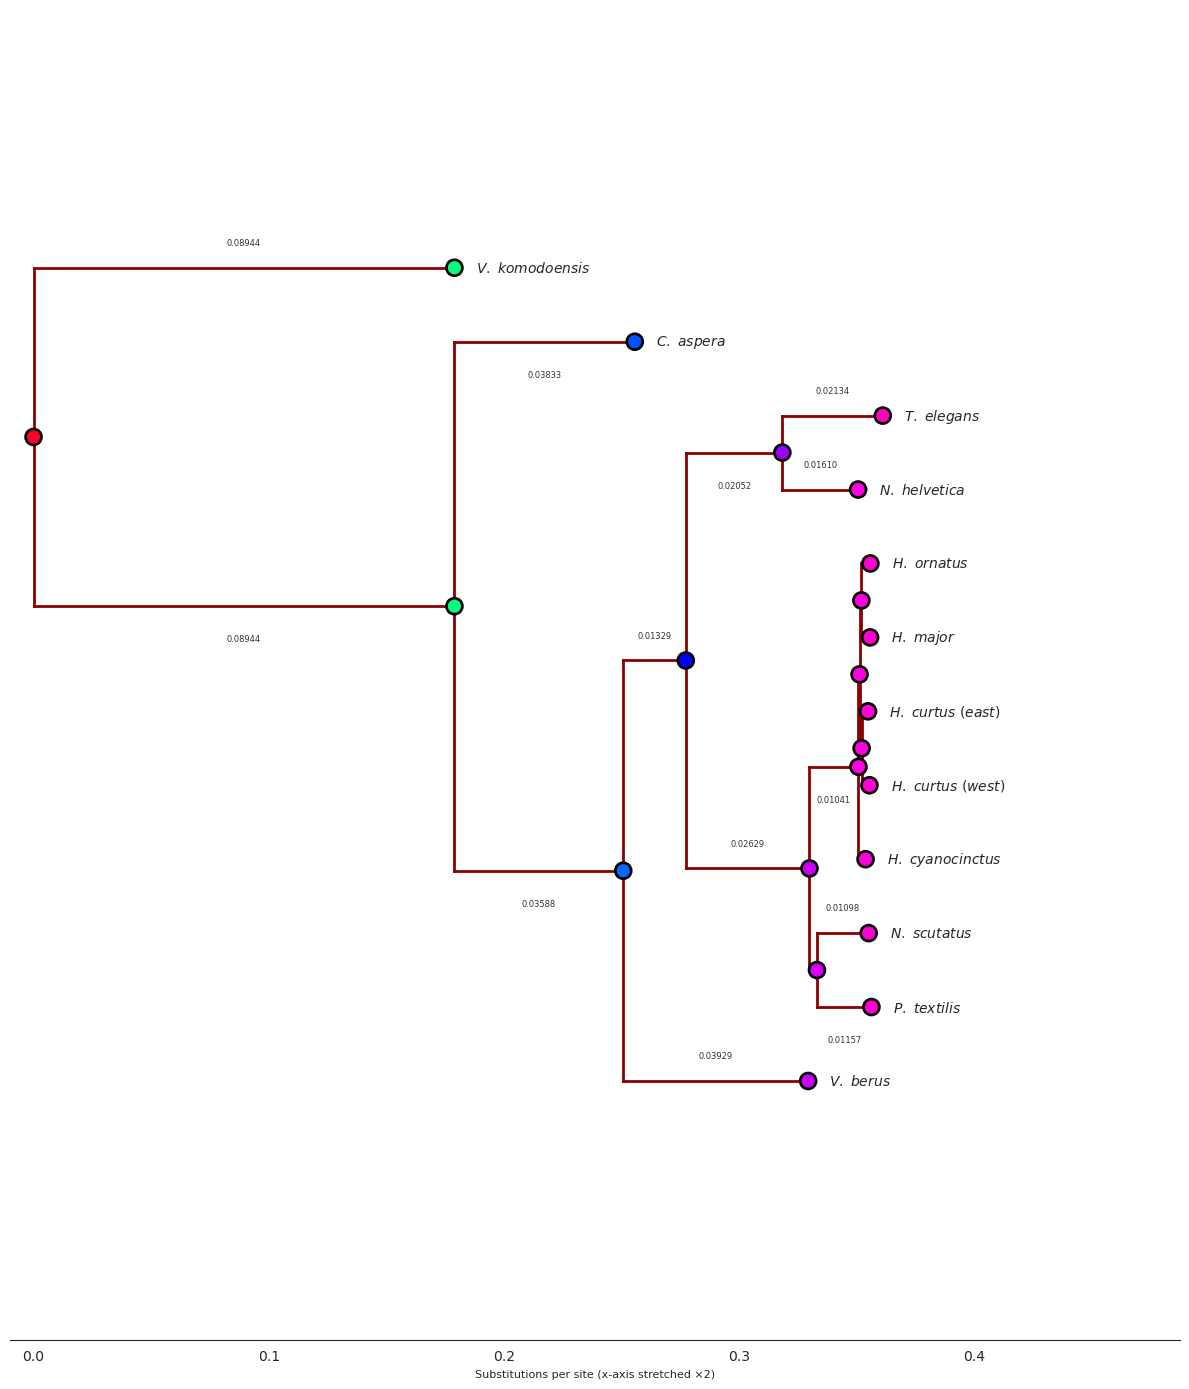

In [141]:
treeFile = Path("/hpcfs/users/a1864358/sanders_lab/phylogenomics/orthofinder/orthofinder_prot/primary_transcripts_lifted/OrthoFinder/Results_lifted/Species_Tree/SpeciesTree_vkomodo_rooted.nwk")
SCALE = 2

ll = bt.loadNewick(str(treeFile), absoluteTime=False)
ll.treeStats()

def _max_terminal_length(k):
    if k.is_leaf():
        return k.length or 0.0
    return max(_max_terminal_length(c) for c in k.children)

def sort_longest_outside(tree, node=None, outer_is_first=True):
    if node is None:
        node = tree.root
    if not getattr(node, "children", None):
        return
    node.children.sort(key=_max_terminal_length, reverse=outer_is_first)
    n = len(node.children)
    for i, child in enumerate(node.children):
        if not child.is_node():
            continue
        if n == 1:
            child_outer_first = outer_is_first
        elif i == 0:
            child_outer_first = True
        elif i == n - 1:
            child_outer_first = False
        else:
            child_outer_first = outer_is_first
        sort_longest_outside(tree, child, child_outer_first)
    if node is tree.root:
        tree.drawTree()

sort_longest_outside(ll)

# Keep outgroup (vkomodo) at the top after ladderizing
OUTGROUP = "vkomodo"
for i, child in enumerate(list(ll.root.children)):
    tips = [child.name] if child.is_leaf() else [lf.name for lf in child.leaves]
    if OUTGROUP in tips:
        ll.root.children.insert(0, ll.root.children.pop(i))
        break
ll.drawTree()

cmap = mpl.cm.gist_rainbow
c_func = lambda k: cmap(k.height / ll.treeHeight)

fig, ax = plt.subplots(figsize=(12, 14), facecolor="white")

x_attr = lambda k: k.height * SCALE

labels = []
for k in ll.Objects:
    bl = getattr(k, "length", None)
    if bl is None or bl < 0.005:
        continue
    # midpoint must use scaled branch length
    labels.append((k, bl, x_attr(k) - (bl * SCALE) / 2))

labels.sort(key=lambda t: (t[0].y, t[2]))
for i, (k, bl, x_mid) in enumerate(labels):
    dy = 0.28 if i % 2 == 0 else -0.38
    ax.text(
        x_mid,
        k.y + dy,
        f"{bl:.5f}",
        ha="center",
        va="bottom" if dy > 0 else "top",
        fontsize=6,
        color="#333333",
        bbox=dict(boxstyle="round,pad=0.20", facecolor="white", edgecolor="none", alpha=0.75),
        zorder=200,
    )

ll.plotTree(ax, x_attr=x_attr, colour="darkred", width=2.0, zorder=10)

ll.plotPoints(
    ax,
    x_attr=x_attr,
    y_attr=lambda k: k.y,
    target=lambda k: k.is_node(),
    size=90,
    colour=c_func,
    zorder=100,
)
ll.plotPoints(
    ax,
    x_attr=x_attr,
    target=lambda k: k.is_leaf(),
    size=90,
    colour=c_func,
    zorder=100,
)

species_names = {
    "hmaj": "H. major",
    "hcure": "H. curtus (east)",
    "hcurw": "H. curtus (west)",
    "hcy": "H. cyanocinctus",
    "horn": "H. ornatus",
    "caspera": "C. aspera",
    "caviridis": "C. viridis",
    "nhel": "N. helvetica",
    "nscut": "N. scutatus",
    "ptext": "P. textilis",
    "tele": "T. elegans",
    "vberus": "V. berus",
    "vkomodo": "V. komodoensis",
}

for k in ll.getExternal():
    if k.is_leaf():
        spec = species_names.get(k.name, k.name)
        spec_i = spec.replace(" ", r"\ ")
        ax.text(
            x_attr(k) + 0.009,
            k.y,
            rf"$\it{{{spec_i}}}$",
            va="center",
            fontsize=10,
        )

ax.set_ylim(-3, ll.ySpan + 3)
ax.set_yticks([])
for loc in ax.spines:
    ax.spines[loc].set_visible(loc == "bottom")

ax.set_xlim(-0.01, ll.treeHeight * SCALE * 1.35)
ax.set_xlabel(f"Substitutions per site (x-axis stretched ×{SCALE})", fontsize=8)

plt.tight_layout()
plt.show()


In [ ]:
# Elapid radiation only: Hydrophis + N. scutatus + P. textilis
from copy import deepcopy

ELAPID_TIPS = ["nscut", "ptext", "hcy", "hcurw", "hcure", "horn", "hmaj"]
SCALE = 3

full = Phylo.read(
    "/hpcfs/users/a1864358/sanders_lab/phylogenomics/orthofinder/orthofinder_prot/primary_transcripts_lifted/OrthoFinder/Results_lifted/Species_Tree/SpeciesTree_vkomodo_rooted.nwk",
    "newick",
)
elapid = deepcopy(full)
for tip in [c.name for c in list(elapid.get_terminals())]:
    if tip not in ELAPID_TIPS:
        elapid.prune(tip)

elapid_nwk = Path(
    "/hpcfs/users/a1864358/sanders_lab/phylogenomics/orthofinder/orthofinder_prot/primary_transcripts_lifted/OrthoFinder/Results_lifted/Species_Tree/SpeciesTree_elapid.nwk"
)
Phylo.write(elapid, elapid_nwk, "newick")
print(elapid)
Phylo.draw_ascii(elapid)

ll = bt.loadNewick(str(elapid_nwk), absoluteTime=False)
ll.treeStats()

def _max_terminal_length(k):
    if k.is_leaf():
        return k.length or 0.0
    return max(_max_terminal_length(c) for c in k.children)

def sort_longest_outside(tree, node=None, outer_is_first=True):
    if node is None:
        node = tree.root
    if not getattr(node, "children", None):
        return
    node.children.sort(key=_max_terminal_length, reverse=outer_is_first)
    n = len(node.children)
    for i, child in enumerate(node.children):
        if not child.is_node():
            continue
        if n == 1:
            child_outer_first = outer_is_first
        elif i == 0:
            child_outer_first = True
        elif i == n - 1:
            child_outer_first = False
        else:
            child_outer_first = outer_is_first
        sort_longest_outside(tree, child, child_outer_first)
    if node is tree.root:
        tree.drawTree()

sort_longest_outside(ll)

cmap = mpl.cm.gist_rainbow
c_func = lambda k: cmap(k.height / ll.treeHeight) if ll.treeHeight else cmap(0)
x_attr = lambda k: k.height * SCALE

fig, ax = plt.subplots(figsize=(10, 8), facecolor="white")

labels = []
for k in ll.Objects:
    bl = getattr(k, "length", None)
    if bl is None or bl < 0.0003:
        continue
    labels.append((k, bl, x_attr(k) - (bl * SCALE) / 2))

labels.sort(key=lambda t: (t[0].y, t[2]))
for i, (k, bl, x_mid) in enumerate(labels):
    dy = 0.22 if i % 2 == 0 else -0.30
    ax.text(
        x_mid,
        k.y + dy,
        f"{bl:.5f}",
        ha="center",
        va="bottom" if dy > 0 else "top",
        fontsize=7,
        color="#333333",
        bbox=dict(boxstyle="round,pad=0.15", facecolor="white", edgecolor="none", alpha=0.75),
        zorder=200,
    )

ll.plotTree(ax, x_attr=x_attr, colour="darkred", width=2.0, zorder=10)
ll.plotPoints(ax, x_attr=x_attr, target=lambda k: k.is_node(), size=80, colour=c_func, zorder=100)
ll.plotPoints(ax, x_attr=x_attr, target=lambda k: k.is_leaf(), size=80, colour=c_func, zorder=100)

species_names = {
    "hmaj": "H. major",
    "hcure": "H. curtus (east)",
    "hcurw": "H. curtus (west)",
    "hcy": "H. cyanocinctus",
    "horn": "H. ornatus",
    "nscut": "N. scutatus",
    "ptext": "P. textilis",
}

for k in ll.getExternal():
    if k.is_leaf():
        spec = species_names.get(k.name, k.name)
        spec_i = spec.replace(" ", r"\ ")
        ax.text(x_attr(k) + 0.0015, k.y, rf"$\it{{{spec_i}}}$", va="center", fontsize=11)

ax.set_ylim(-1.5, ll.ySpan + 1.5)
ax.set_yticks([])
for loc in ax.spines:
    ax.spines[loc].set_visible(loc == "bottom")
ax.set_xlim(-0.002, ll.treeHeight * SCALE * 1.45)
ax.set_xlabel(f"Substitutions per site (x-axis stretched ×{SCALE})", fontsize=8)
ax.set_title("Elapid radiation (Hydrophis + N. scutatus + P. textilis)", fontsize=11)

plt.tight_layout()
plt.show()
